# Electricity Demand Forecasting Using Machine Learning and Time Series Models

# Introduction

Accurately forecasting electricity demand is essential for maintaining a reliable and efficient power system. Utility companies and grid operators depend on demand forecasts to balance electricity generation with consumption, reduce operational costs, prevent outages, and support long-term energy planning. Even small improvements in forecasting accuracy can lead to significant economic and operational benefits.

In this project, historical electricity consumption data is analyzed to build predictive models capable of estimating future electricity demand. The workflow begins with data preprocessing, exploratory data analysis, and feature engineering to uncover meaningful patterns within the dataset. Multiple forecasting approaches are then developed and evaluated, including Baseline forecasting, Random Forest, XGBoost, ARIMA, SARIMA, and Prophet.

The models are compared using standard evaluation metrics such as Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score to identify the most effective forecasting technique. This project demonstrates how both machine learning and traditional time series methods can be applied to real-world energy forecasting problems and highlights the strengths and limitations of each approach.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
aep=pd.read_csv("/kaggle/input/datasets/kishorek255/aep-hourly-data/AEP_hourly.csv")

In [3]:
aep.head()

,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0


In [4]:
aep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121273 entries, 0 to 121272
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  121273 non-null  object 
 1   AEP_MW    121273 non-null  float64
dtypes: float64(1), object(1)
memory usage: 1.9+ MB


In [5]:
aep.describe()

,AEP_MW
count,121273.000000
mean,15499.513717
std,2591.399065
min,9581.000000
25%,13630.000000
50%,15310.000000
75%,17200.000000
max,25695.000000


**The dataset was inspected for missing values, incorrect data types, and summary statistics. The Datetime column was converted into datetime format to enable time-based feature extraction.**

In [7]:
aep.isna().sum()

Datetime    0
AEP_MW      0
dtype: int64

In [8]:
aep.isnull().sum()

Datetime    0
AEP_MW      0
dtype: int64

In [9]:
aep.columns

Index(['Datetime', 'AEP_MW'], dtype='object')

In [10]:
aep["Datetime"]=pd.to_datetime(aep["Datetime"])

In [11]:
aep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121273 entries, 0 to 121272
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   Datetime  121273 non-null  datetime64[ns]
 1   AEP_MW    121273 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 1.9 MB


In [12]:
aep.head(10)

,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0
5,2004-12-31 06:00:00,13038.0
6,2004-12-31 07:00:00,13692.0
7,2004-12-31 08:00:00,14297.0
8,2004-12-31 09:00:00,14719.0
9,2004-12-31 10:00:00,14941.0


In [13]:
aep["year"]=aep["Datetime"].dt.year
aep["month"]=aep["Datetime"].dt.month
aep["hour"]=aep["Datetime"].dt.hour
aep["dayofweek"]=aep["Datetime"].dt.dayofweek

In [14]:
aep.groupby("hour")["AEP_MW"].mean().sort_values(ascending=False)

hour
19    16868.728334
20    16821.335180
21    16763.806292
18    16762.940047
17    16542.038781
14    16534.660202
15    16492.810645
13    16477.793035
22    16468.967550
16    16444.506134
12    16398.177087
11    16306.315592
10    16084.283934
9     15822.653740
23    15632.594183
8     15478.830233
7     14781.668381
0     14651.191569
1     13891.478433
6     13802.401464
2     13432.062995
5     13240.535813
3     13184.049008
4     13095.193350
Name: AEP_MW, dtype: float64

In [15]:
aep.groupby("month")["AEP_MW"].mean().sort_values(ascending=False)

month
1     17431.269009
2     17022.815084
12    16445.609084
8     16424.881699
7     16349.853303
6     15630.021825
3     15376.835720
11    14930.405676
9     14657.280556
5     14006.393817
10    13938.926431
4     13823.857511
Name: AEP_MW, dtype: float64

In [16]:
aep.groupby("dayofweek")["AEP_MW"].mean().sort_values(ascending=False)

dayofweek
1    16057.615571
3    16028.138281
2    16013.589739
0    15810.973684
4    15773.123911
5    14610.979628
6    14200.754680
Name: AEP_MW, dtype: float64

In [17]:
aep.groupby("year")["AEP_MW"].mean().sort_values(ascending=False)

year
2007    16645.519297
2008    16536.655659
2010    16008.619504
2005    15842.990865
2011    15815.389472
2006    15737.224252
2012    15352.940667
2018    15290.612734
2009    15254.111669
2013    15198.211578
2004    15176.724388
2014    15169.078890
2015    14868.922603
2016    14784.225979
2017    14483.738356
Name: AEP_MW, dtype: float64

In [18]:
aep["Datetime"]

0        2004-12-31 01:00:00
1        2004-12-31 02:00:00
2        2004-12-31 03:00:00
3        2004-12-31 04:00:00
4        2004-12-31 05:00:00
                 ...        
121268   2018-01-01 20:00:00
121269   2018-01-01 21:00:00
121270   2018-01-01 22:00:00
121271   2018-01-01 23:00:00
121272   2018-01-02 00:00:00
Name: Datetime, Length: 121273, dtype: datetime64[ns]

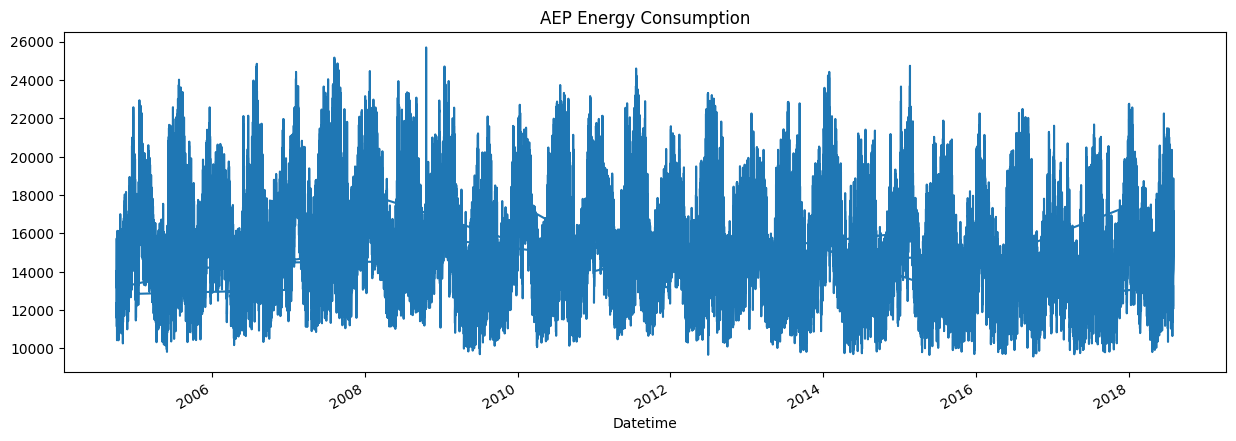

In [19]:
aep.set_index("Datetime")["AEP_MW"].plot(figsize=(15,5),title="AEP Energy Consumption")
plt.show()

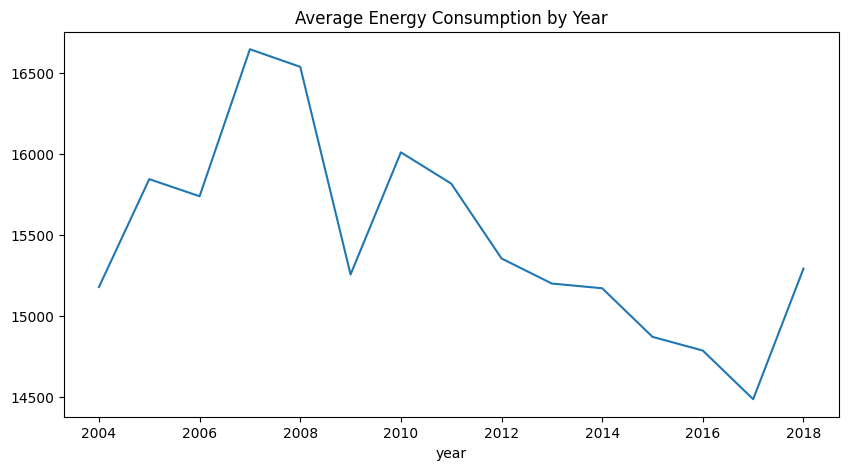

In [20]:
yearly_mean=aep.groupby("year")["AEP_MW"].mean()
yearly_mean.plot(figsize=(10,5), title="Average Energy Consumption by Year")
plt.show()

In [21]:
yearly_mean=aep.groupby("year")["AEP_MW"].mean()

print(yearly_mean)

year
2004    15176.724388
2005    15842.990865
2006    15737.224252
2007    16645.519297
2008    16536.655659
2009    15254.111669
2010    16008.619504
2011    15815.389472
2012    15352.940667
2013    15198.211578
2014    15169.078890
2015    14868.922603
2016    14784.225979
2017    14483.738356
2018    15290.612734
Name: AEP_MW, dtype: float64


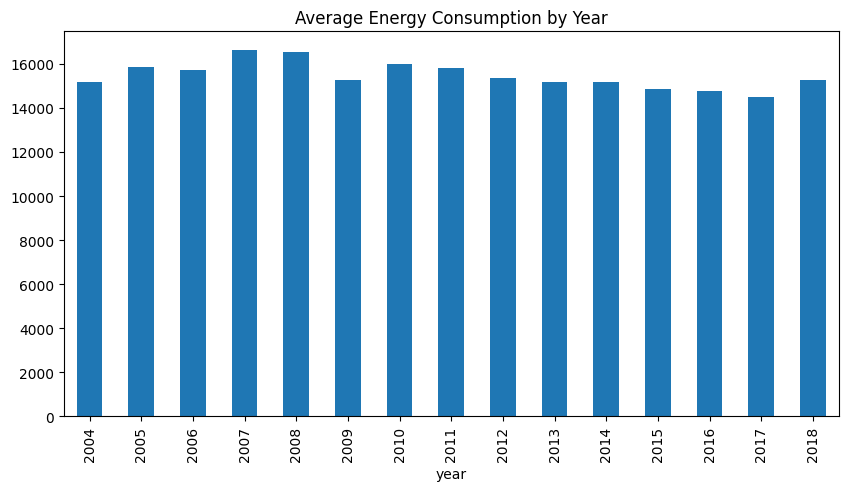

In [22]:
yearly_mean=aep.groupby("year")["AEP_MW"].mean()
yearly_mean.plot(kind="bar",figsize=(10,5), title="Average Energy Consumption by Year")
plt.show()

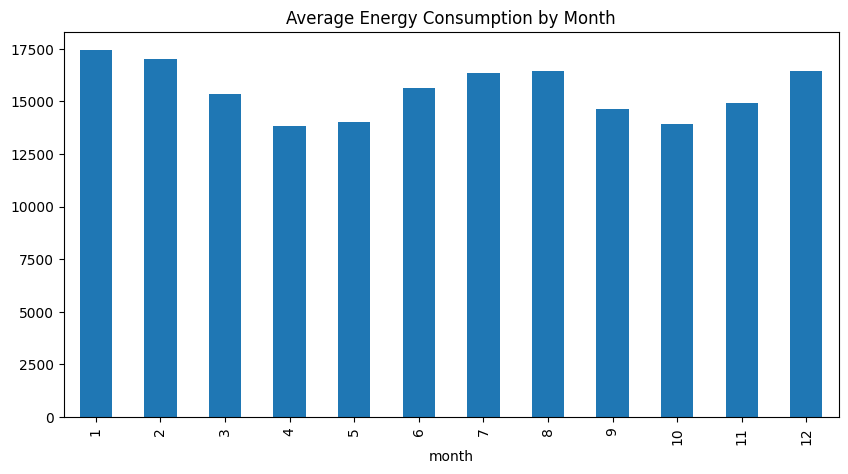

In [23]:
monthly_mean=aep.groupby("month")["AEP_MW"].mean()
monthly_mean.plot(kind="bar",figsize=(10,5), title="Average Energy Consumption by Month")
plt.show()

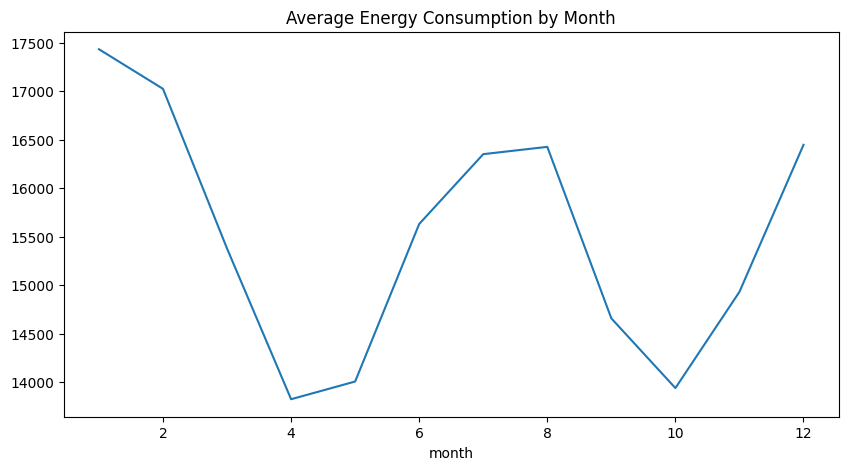

In [24]:
monthly_mean=aep.groupby("month")["AEP_MW"].mean()
monthly_mean.plot(figsize=(10,5), title="Average Energy Consumption by Month")
plt.show()

/tmp/ipykernel_701/265649849.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  aep.set_index("Datetime")["AEP_MW"].resample("Y").mean().plot(figsize=(15,5))


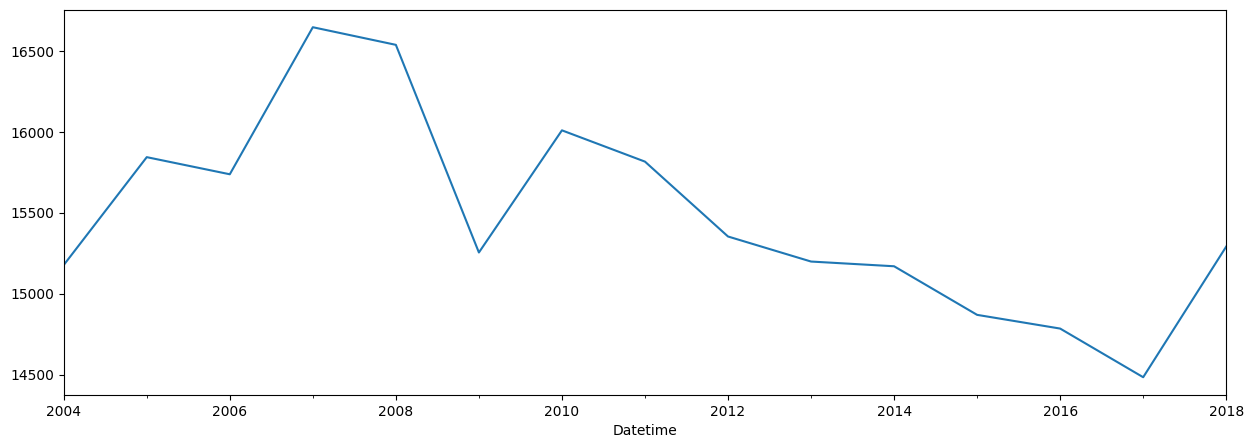

In [25]:
aep.set_index("Datetime")["AEP_MW"].resample("Y").mean().plot(figsize=(15,5))
plt.show()

/tmp/ipykernel_701/3176175865.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  aep.set_index("Datetime")["AEP_MW"].resample("M").mean().plot(figsize=(15,5))


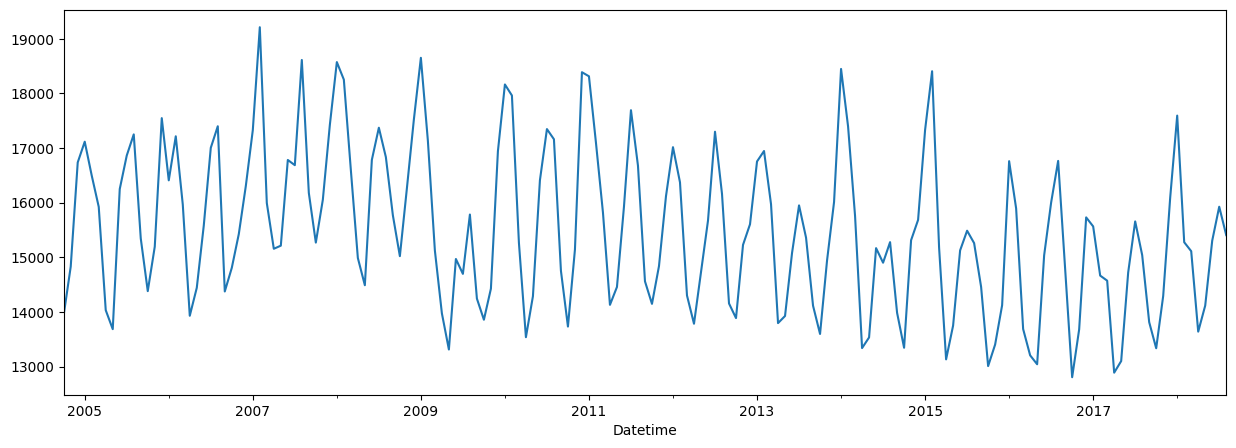

In [26]:
aep.set_index("Datetime")["AEP_MW"].resample("M").mean().plot(figsize=(15,5))
plt.show()

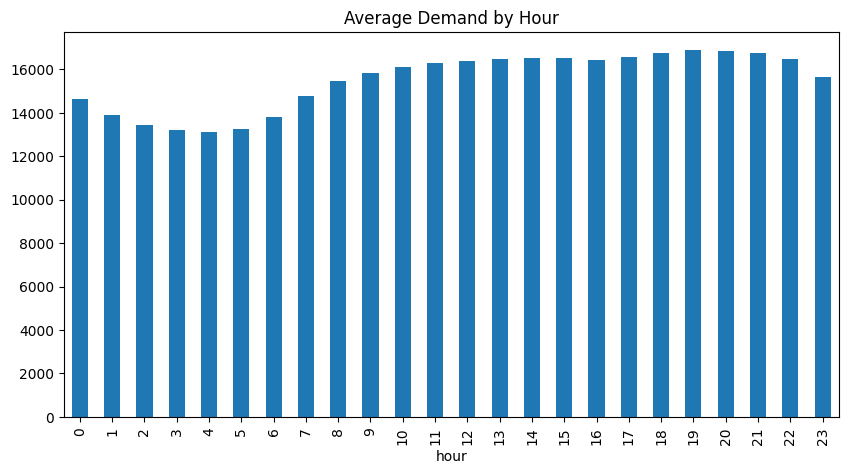

In [27]:
aep.groupby("hour")["AEP_MW"].mean().plot(kind="bar", figsize=(10,5), title="Average Demand by Hour")
plt.show()

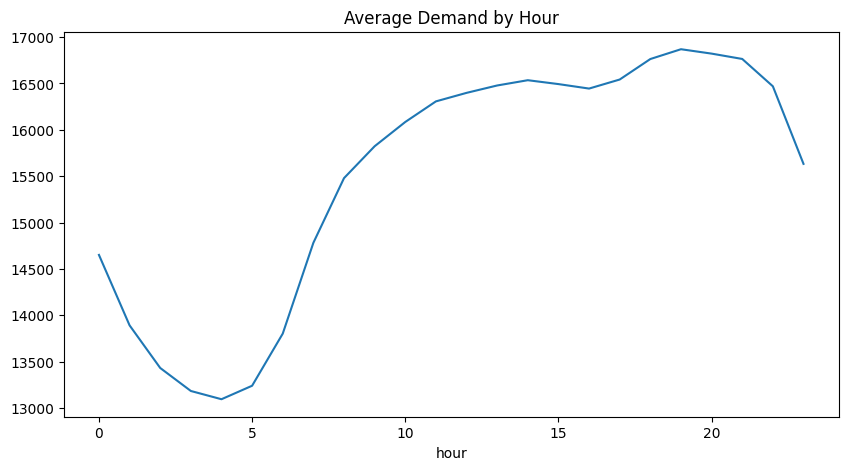

In [28]:
aep.groupby("hour")["AEP_MW"].mean().plot(figsize=(10,5), title="Average Demand by Hour")
plt.show()

/tmp/ipykernel_701/1263369025.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = aep.set_index("Datetime")["AEP_MW"].resample("M").mean()


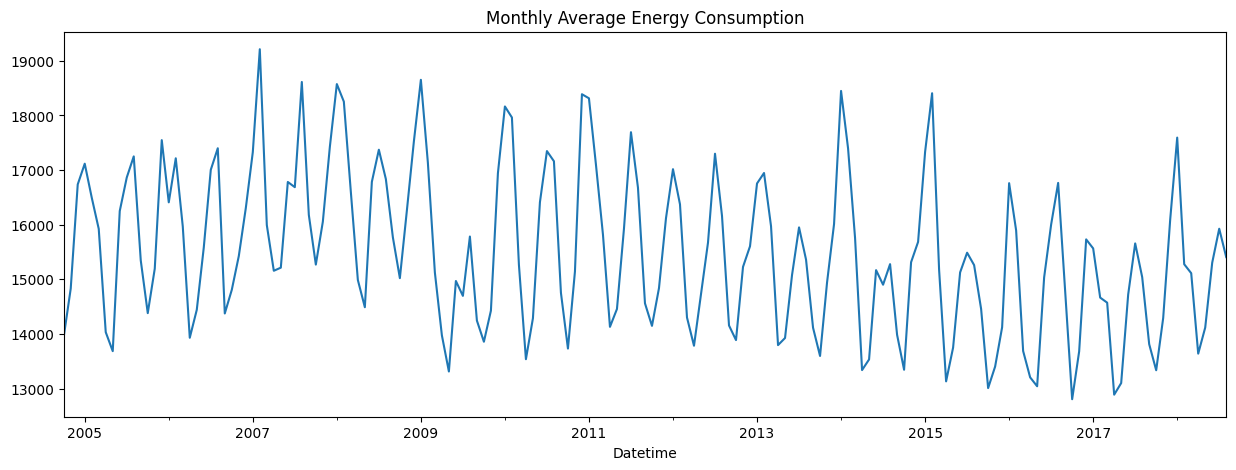

In [29]:
monthly = aep.set_index("Datetime")["AEP_MW"].resample("M").mean()

monthly.plot(figsize=(15,5))
plt.title("Monthly Average Energy Consumption")
plt.show()

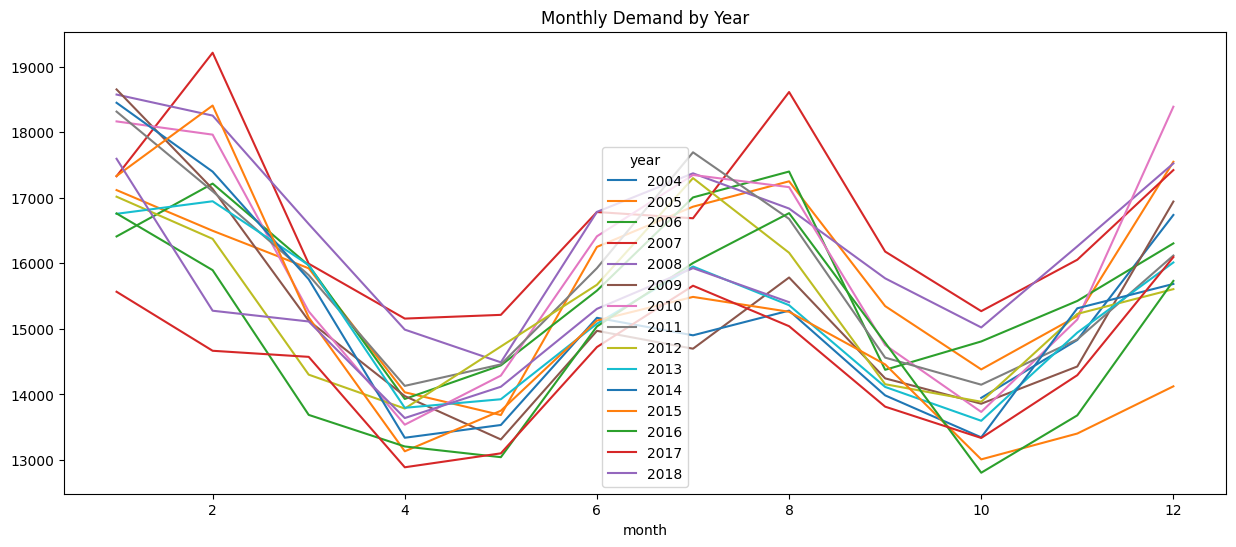

In [30]:
yearly = aep.groupby(["year","month"])["AEP_MW"].mean().unstack(0)

yearly.plot(figsize=(15,6))
plt.title("Monthly Demand by Year")
plt.show()

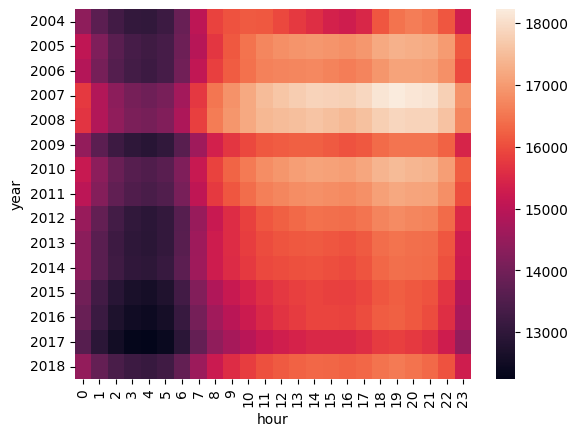

In [31]:
import seaborn as sns

pivot=aep.pivot_table(values="AEP_MW", index="year", columns="hour", aggfunc="mean")

sns.heatmap(pivot)
plt.show()

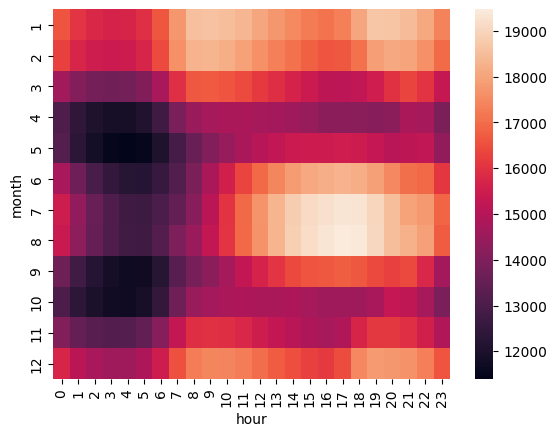

In [32]:
import seaborn as sns

pivot=aep.pivot_table(values="AEP_MW", index="month", columns="hour", aggfunc="mean")

sns.heatmap(pivot)
plt.show()

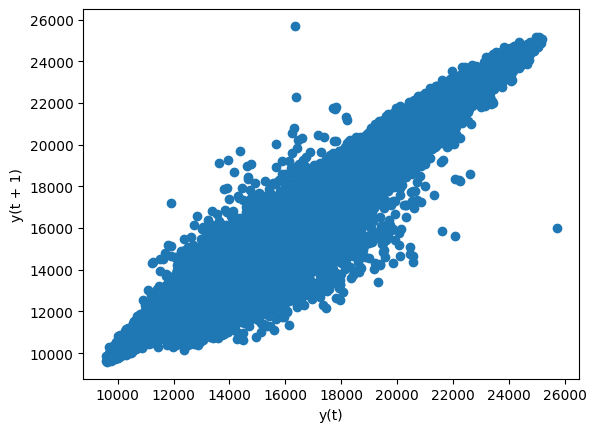

In [33]:
from pandas.plotting import lag_plot

lag_plot(aep["AEP_MW"])
plt.show()

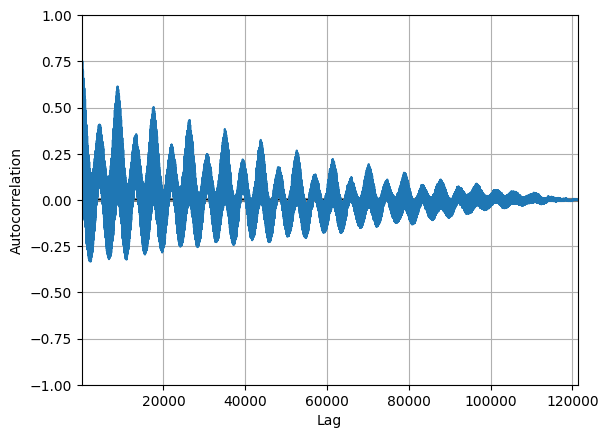

In [34]:
from pandas.plotting import autocorrelation_plot

autocorrelation_plot(aep["AEP_MW"])
plt.show()

In [35]:
aep["lag_1"]=aep["AEP_MW"].shift(1)
aep["lag_24"]=aep["AEP_MW"].shift(24)
aep["lag_168"]=aep["AEP_MW"].shift(168)

In [36]:
aep["AEP_MW"].shift(3)

0             NaN
1             NaN
2             NaN
3         13478.0
4         12865.0
           ...   
121268    19109.0
121269    20279.0
121270    20925.0
121271    21089.0
121272    20999.0
Name: AEP_MW, Length: 121273, dtype: float64

In [37]:
aep.head(30)

,Datetime,AEP_MW,year,month,hour,dayofweek,lag_1,lag_24,lag_168
0,2004-12-31 01:00:00,13478.0,2004,12,1,4,NaN,NaN,NaN
1,2004-12-31 02:00:00,12865.0,2004,12,2,4,13478.0,NaN,NaN
2,2004-12-31 03:00:00,12577.0,2004,12,3,4,12865.0,NaN,NaN
3,2004-12-31 04:00:00,12517.0,2004,12,4,4,12577.0,NaN,NaN
4,2004-12-31 05:00:00,12670.0,2004,12,5,4,12517.0,NaN,NaN
5,2004-12-31 06:00:00,13038.0,2004,12,6,4,12670.0,NaN,NaN
6,2004-12-31 07:00:00,13692.0,2004,12,7,4,13038.0,NaN,NaN
7,2004-12-31 08:00:00,14297.0,2004,12,8,4,13692.0,NaN,NaN
8,2004-12-31 09:00:00,14719.0,2004,12,9,4,14297.0,NaN,NaN
9,2004-12-31 10:00:00,14941.0,2004,12,10,4,14719.0,NaN,NaN


In [38]:
aep.head(169)

,Datetime,AEP_MW,year,month,hour,dayofweek,lag_1,lag_24,lag_168
0,2004-12-31 01:00:00,13478.0,2004,12,1,4,NaN,NaN,NaN
1,2004-12-31 02:00:00,12865.0,2004,12,2,4,13478.0,NaN,NaN
2,2004-12-31 03:00:00,12577.0,2004,12,3,4,12865.0,NaN,NaN
3,2004-12-31 04:00:00,12517.0,2004,12,4,4,12577.0,NaN,NaN
4,2004-12-31 05:00:00,12670.0,2004,12,5,4,12517.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...
164,2004-12-25 21:00:00,16842.0,2004,12,21,5,16678.0,18086.0,NaN
165,2004-12-25 22:00:00,16621.0,2004,12,22,5,16842.0,17834.0,NaN
166,2004-12-25 23:00:00,16167.0,2004,12,23,5,16621.0,17392.0,NaN
167,2004-12-26 00:00:00,15676.0,2004,12,0,6,16167.0,16842.0,NaN


In [39]:
aep["AEP_MW"].rolling(24*7).mean()

0                  NaN
1                  NaN
2                  NaN
3                  NaN
4                  NaN
              ...     
121268    20407.464286
121269    20423.065476
121270    20441.000000
121271    20461.232143
121272    20483.523810
Name: AEP_MW, Length: 121273, dtype: float64

In [40]:
aep["rolling_24"] = aep["AEP_MW"].rolling(24).mean()

In [41]:
aep.drop(columns=["rolling_24"],inplace=True)

In [42]:
aep.head()

,Datetime,AEP_MW,year,month,hour,dayofweek,lag_1,lag_24,lag_168
0,2004-12-31 01:00:00,13478.0,2004,12,1,4,NaN,NaN,NaN
1,2004-12-31 02:00:00,12865.0,2004,12,2,4,13478.0,NaN,NaN
2,2004-12-31 03:00:00,12577.0,2004,12,3,4,12865.0,NaN,NaN
3,2004-12-31 04:00:00,12517.0,2004,12,4,4,12577.0,NaN,NaN
4,2004-12-31 05:00:00,12670.0,2004,12,5,4,12517.0,NaN,NaN


In [43]:
aep=aep.dropna()

In [44]:
aep = aep.sort_index()

aep.index = pd.to_datetime(aep.index)

In [45]:
aep.head(5)

,Datetime,AEP_MW,year,month,hour,dayofweek,lag_1,lag_24,lag_168
1970-01-01 00:00:00.000000168,2004-12-24 01:00:00,15645.0,2004,12,1,4,15676.0,16669.0,13478.0
1970-01-01 00:00:00.000000169,2004-12-24 02:00:00,15265.0,2004,12,2,4,15645.0,16218.0,12865.0
1970-01-01 00:00:00.000000170,2004-12-24 03:00:00,15138.0,2004,12,3,4,15265.0,16135.0,12577.0
1970-01-01 00:00:00.000000171,2004-12-24 04:00:00,15068.0,2004,12,4,4,15138.0,16107.0,12517.0
1970-01-01 00:00:00.000000172,2004-12-24 05:00:00,15122.0,2004,12,5,4,15068.0,16229.0,12670.0


In [46]:
x=aep[["year","month","hour","dayofweek","lag_1","lag_24","lag_168"]]
y=aep["AEP_MW"]

In [47]:
x

,year,month,hour,dayofweek,lag_1,lag_24,lag_168
1970-01-01 00:00:00.000000168,2004,12,1,4,15676.0,16669.0,13478.0
1970-01-01 00:00:00.000000169,2004,12,2,4,15645.0,16218.0,12865.0
1970-01-01 00:00:00.000000170,2004,12,3,4,15265.0,16135.0,12577.0
1970-01-01 00:00:00.000000171,2004,12,4,4,15138.0,16107.0,12517.0
1970-01-01 00:00:00.000000172,2004,12,5,4,15068.0,16229.0,12670.0
...,...,...,...,...,...,...,...
1970-01-01 00:00:00.000121268,2018,1,20,0,20925.0,21971.0,18733.0
1970-01-01 00:00:00.000121269,2018,1,21,0,21089.0,21942.0,18378.0
1970-01-01 00:00:00.000121270,2018,1,22,0,20999.0,21695.0,17807.0
1970-01-01 00:00:00.000121271,2018,1,23,0,20820.0,21230.0,17016.0


In [48]:
y

1970-01-01 00:00:00.000000168    15645.0
1970-01-01 00:00:00.000000169    15265.0
1970-01-01 00:00:00.000000170    15138.0
1970-01-01 00:00:00.000000171    15068.0
1970-01-01 00:00:00.000000172    15122.0
                                  ...   
1970-01-01 00:00:00.000121268    21089.0
1970-01-01 00:00:00.000121269    20999.0
1970-01-01 00:00:00.000121270    20820.0
1970-01-01 00:00:00.000121271    20415.0
1970-01-01 00:00:00.000121272    19993.0
Name: AEP_MW, Length: 121105, dtype: float64

# For a time series, splitting has to be done manually not from a library, coz this shuffles randomly which cannot be applicable in a time series.

# Random Forest

**Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy while reducing overfitting.**

In [49]:
split=int(len(aep)*0.8)

In [50]:
split

96884

In [51]:
x_train=x[:split]
x_test=x[split:]

y_train=y[:split]
y_test=y[split:]

In [52]:
from sklearn.ensemble import RandomForestRegressor
r=RandomForestRegressor(n_estimators=100,random_state=42,n_jobs=-1)

In [53]:
r.fit(x_train,y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [54]:
pred=r.predict(x_test)

In [55]:
pred

array([17546.72, 18458.14, 18839.25, ..., 20700.14, 20130.47, 19712.25],
      shape=(24221,))

In [56]:
from sklearn.metrics import mean_absolute_error, r2_score

rf_mae=mean_absolute_error(y_test,pred)
rf_r2=r2_score(y_test,pred)

In [57]:
print("MAE:", rf_mae)
print("R2:", rf_r2)

MAE: 173.47782089921972
R2: 0.9878287985746925


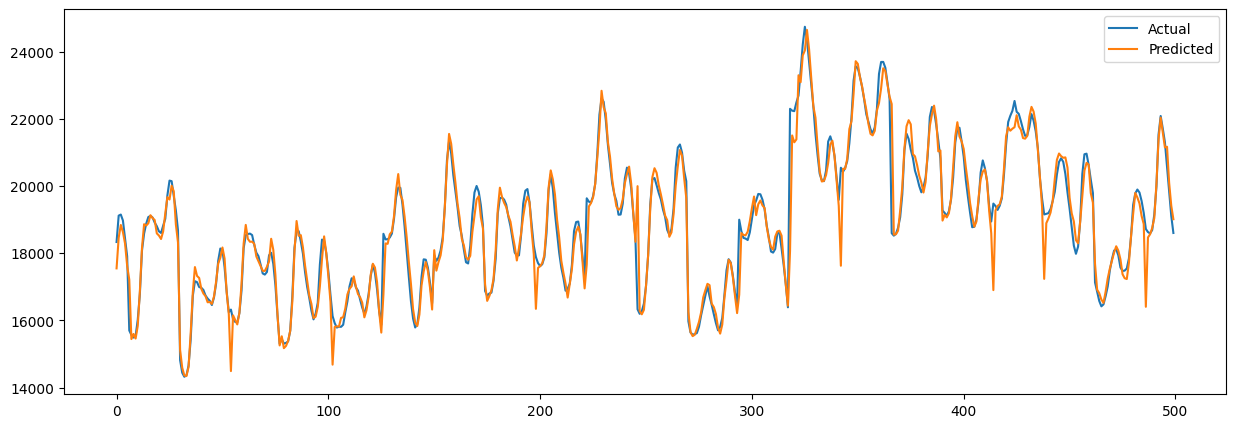

In [58]:
plt.figure(figsize=(15,5))

plt.plot(y_test.values[:500], label="Actual")
plt.plot(pred[:500], label="Predicted")

plt.legend()
plt.show()

# MAE is 173.47 says that the error is very less resulting in a good model and R2 explains a 98.7% variation in the actual and predicted values.

# Baseline Model or Linear Regression

In [59]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)
pred_lr=lr.predict(x_test)

In [60]:
pred_lr

array([16978.86321517, 17735.85824178, 18365.26720798, ...,
       21029.67822871, 20764.62949259, 20272.88753228], shape=(24221,))

In [61]:
lr_mae=mean_absolute_error(y_test, pred_lr)
lr_r2=r2_score(y_test, pred_lr)

In [62]:
print("MAE:", mean_absolute_error(y_test, pred_lr))
print("R2:", r2_score(y_test, pred_lr))

MAE: 404.2755500367472
R2: 0.9538078902054845


**Actual vs Prediction Plot**

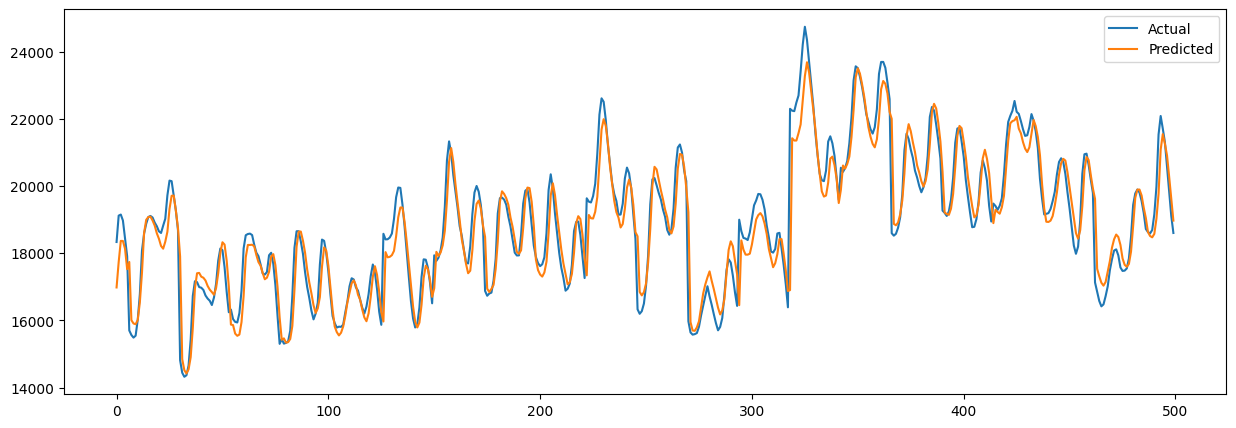

In [63]:
plt.figure(figsize=(15,5))

plt.plot()
plt.plot(y_test.values[:500], label="Actual")
plt.plot(pred_lr[:500], label="Predicted")

plt.legend()
plt.show()

# XGBoost

In [113]:
aep

,AEP_MW,year,month,hour,dayofweek,lag_1,lag_24,lag_168
Datetime,,,,,,,,
2004-10-01 01:00:00,12379.0,2004,10,1,4,12172.0,12260.0,12468.0
2004-10-01 02:00:00,11935.0,2004,10,2,4,12379.0,11672.0,12046.0
2004-10-01 03:00:00,11692.0,2004,10,3,4,11935.0,11352.0,11749.0
2004-10-01 04:00:00,11597.0,2004,10,4,4,11692.0,11177.0,11784.0
2004-10-01 05:00:00,11681.0,2004,10,5,4,11597.0,11142.0,11919.0
...,...,...,...,...,...,...,...,...
2018-08-02 20:00:00,17673.0,2018,8,20,3,18118.0,13962.0,19982.0
2018-08-02 21:00:00,17303.0,2018,8,21,3,17673.0,13770.0,19939.0
2018-08-02 22:00:00,17001.0,2018,8,22,3,17303.0,13508.0,19627.0


In [109]:
from xgboost import XGBRegressor
xgb=XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
xgb.fit(x_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [110]:
pred_xgb=xgb.predict(x_test)

In [111]:
xgb_mae=mean_absolute_error(y_test, pred_xgb)
xgb_r2=r2_score(y_test, pred_xgb)

In [112]:
print("MAE:", mean_absolute_error(y_test, pred_xgb))
print("R2:", r2_score(y_test, pred_xgb))

MAE: 182.96453079520353
R2: 0.9874600233285797


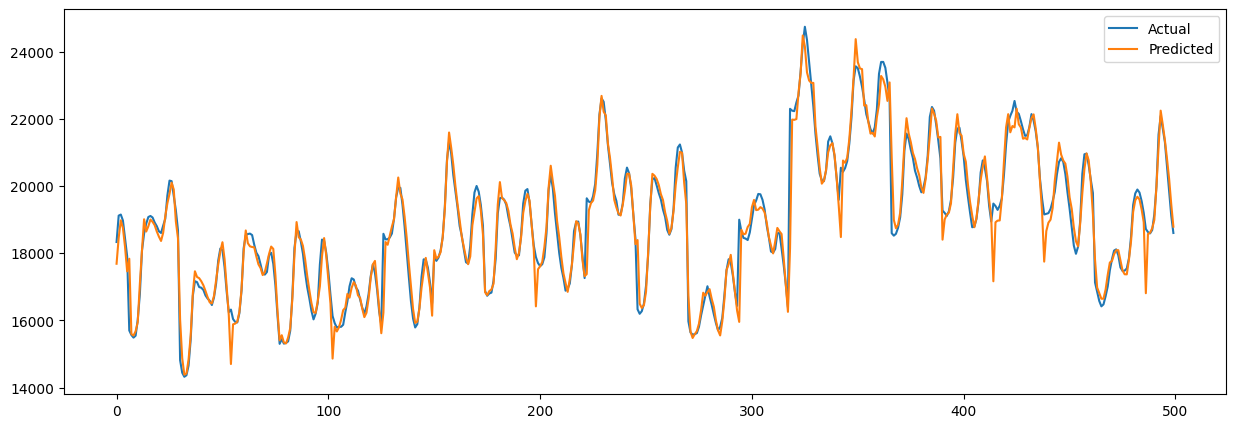

In [68]:
plt.figure(figsize=(15,5))

plt.plot(y_test.values[:500], label="Actual")
plt.plot(pred_xgb[:500], label="Predicted")

plt.legend()
plt.show()

In [69]:
aep.describe()

,Datetime,AEP_MW,year,month,hour,dayofweek,lag_1,lag_24,lag_168
count,121105,121105.000000,121105.000000,121105.000000,121105.00000,121105.000000,121105.000000,121105.000000,121105.000000
mean,2011-09-05 12:28:25.098880768,15498.349969,2011.179927,6.492771,11.50159,2.999513,15498.314322,15497.704983,15492.599769
min,2004-10-01 01:00:00,9581.000000,2004.000000,1.000000,0.00000,0.000000,9581.000000,9581.000000,9581.000000
25%,2008-03-22 21:00:00,13628.000000,2008.000000,3.000000,6.00000,1.000000,13628.000000,13628.000000,13628.000000
50%,2011-09-05 16:00:00,15308.000000,2011.000000,6.000000,12.00000,3.000000,15308.000000,15308.000000,15305.000000
75%,2015-02-18 11:00:00,17200.000000,2015.000000,10.000000,18.00000,5.000000,17200.000000,17199.000000,17191.000000
max,2018-08-03 00:00:00,25695.000000,2018.000000,12.000000,23.00000,6.000000,25695.000000,25695.000000,25695.000000
std,NaN,2592.181872,4.005066,3.457784,6.92183,1.999816,2592.149745,2591.580354,2586.126459


# Feature Importance Plot

**Feature importance indicates the relative contribution of each input feature to the Random Forest model's predictions. Higher importance values suggest that a feature has a greater influence on forecasting electricity demand.**

     Feature  Importance
4      lag_1    0.940611
2       hour    0.038888
5     lag_24    0.008952
1      month    0.005146
6    lag_168    0.002579
3  dayofweek    0.002508
0       year    0.001316


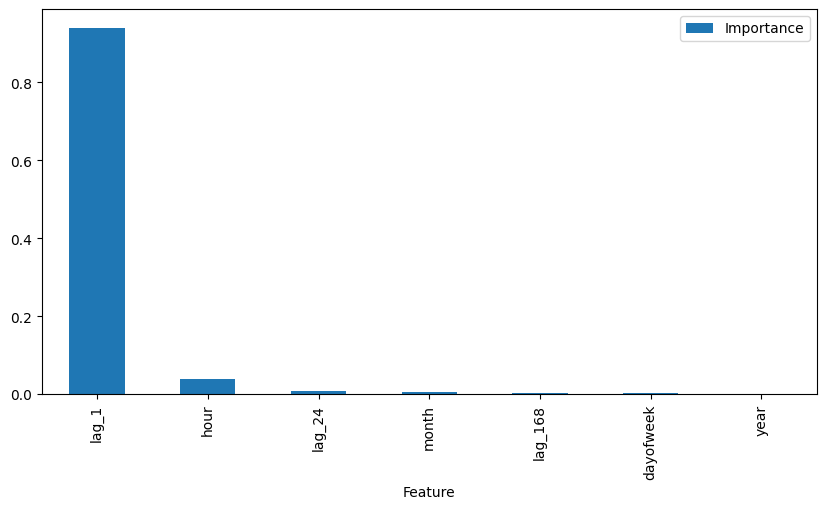

In [70]:
importance=pd.DataFrame({"Feature": x_train.columns, "Importance": r.feature_importances_})

importance=importance.sort_values(by="Importance", ascending=False)

print(importance)

importance.plot(x="Feature", y="Importance", kind="bar", figsize=(10,5))

plt.show()

**Random Forest has a 94% of the prediction from the lag_1**

**So, the demand of the previous hour is enough to predict the current hour.**

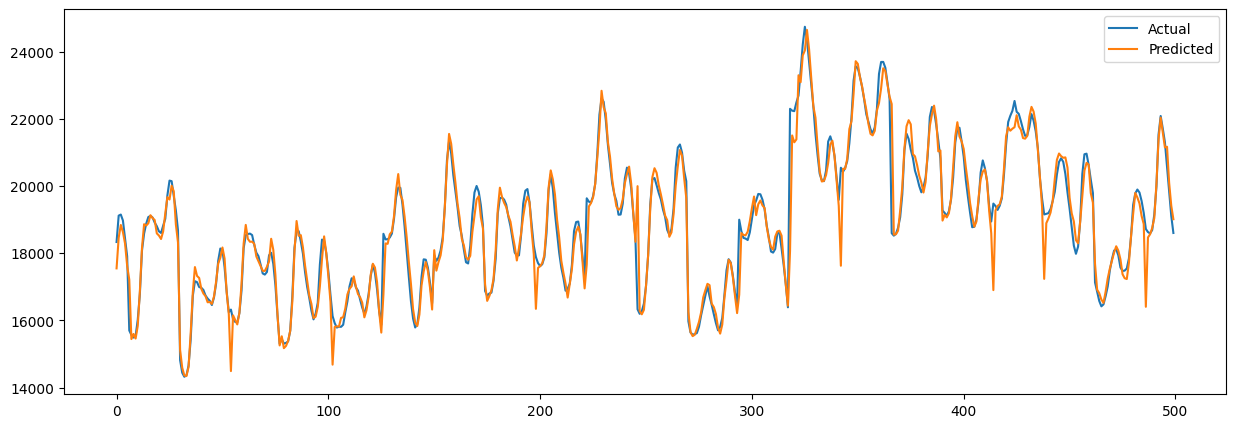

In [71]:
plt.figure(figsize=(15,5))

plt.plot(y_test.values[:500], label="Actual")
plt.plot(pred[:500], label="Predicted")

plt.legend()
plt.show()

**The Actual vs Predicted plot shows that the Random Forest model closely follows the observed electricity demand patterns.** 

**The predicted values successfully capture both peaks and troughs, indicating that the model has learned the temporal structure of the data effectively.**

# Residual Analysis

**Residual analysis evaluates the prediction errors of the Random Forest model. It helps determine whether the model systematically overestimates or underestimates electricity demand and whether the errors are randomly distributed.**

**An effective forecasting model should have residuals centered around zero with no obvious pattern. A random distribution of positive and negative residuals indicates that the model has captured the underlying relationship without significant systematic bias.**

In [72]:
residuals=y_test-pred

print("Mean Residual:", residuals.mean())
print("Max Residual:", residuals.max())
print("Min Residual:", residuals.min())

Mean Residual: -10.044269848478589
Max Residual: 4229.1500000000015
Min Residual: -4299.779999999999


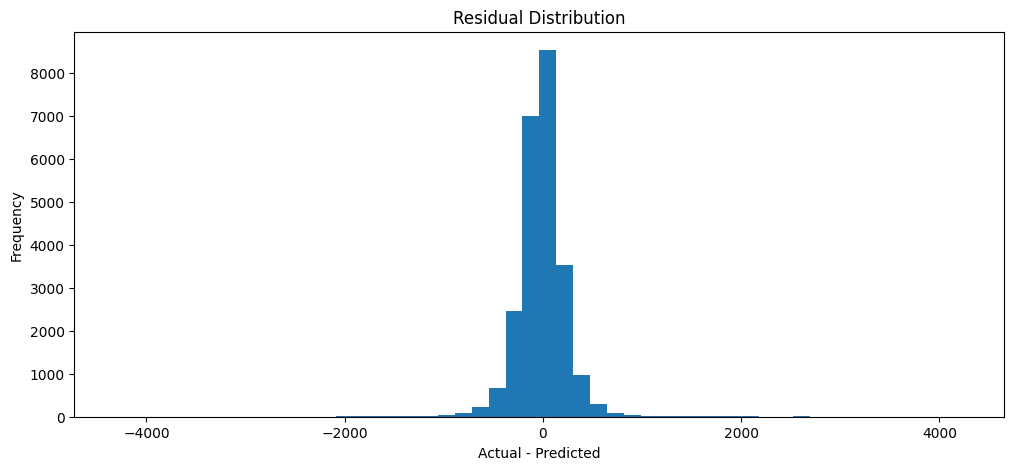

In [73]:
plt.figure(figsize=(12,5))
plt.hist(residuals, bins=50)
plt.title("Residual Distribution")
plt.xlabel("Actual - Predicted")
plt.ylabel("Frequency")
plt.show()

**From the plots, it can be concluded that the residuals are concentrated around 0 and few tails lying on both the either side of the x-axis towards 4400, resulting in no bias.**

In [74]:
residuals.sort_values().head(10)

1970-01-01 00:00:00.000097802   -4299.78
1970-01-01 00:00:00.000097418   -3844.73
1970-01-01 00:00:00.000097298   -3666.45
1970-01-01 00:00:00.000115178   -3356.55
1970-01-01 00:00:00.000107138   -3157.50
1970-01-01 00:00:00.000120985   -3097.27
1970-01-01 00:00:00.000116042   -2974.11
1970-01-01 00:00:00.000097730   -2862.00
1970-01-01 00:00:00.000114794   -2858.57
1970-01-01 00:00:00.000097634   -2766.78
Name: AEP_MW, dtype: float64

# Classical Forecasting

# Arima

**Arima needs the time series to be stationary.**

**ADF Test can be used to check whether the tine series is stationary or not**

**If, p-value < 0.05, it is stationary and if not, it is not stationary.**

In [75]:
from statsmodels.tsa.stattools import adfuller

result=adfuller(aep["AEP_MW"])

print("ADF Statistic:", result[0])

ADF Statistic: -16.440305173948207


In [76]:
print("p-value", result[1])

p-value 2.431367974329155e-29


# This is evident that this a stationary time series as the null hypothesis is not rejected (p-value < 0.05).**

# Arima(p, d, q)

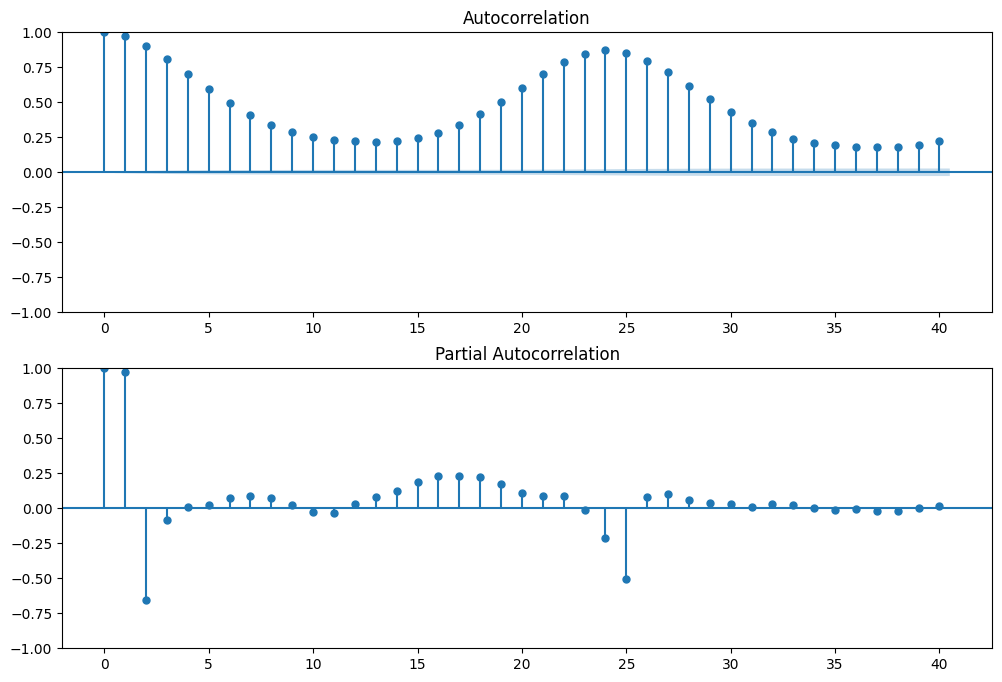

In [77]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

fig,ax=plt.subplots(2,1,figsize=(12,8))

plot_acf(aep["AEP_MW"],lags=40,ax=ax[0])

plot_pacf(aep["AEP_MW"],lags=40,ax=ax[1])

plt.show()

**In the Autocorrelation plot, lag1 has a strong correlation of around 0.98 and lag24 has a strong correlation of around 0.84, which depicts that for every hour and every 24 hours, the consumption of MW is slighly similar.** 

**There is no sudden cut-off in the ACF plot, so the value of AutoRegressive(q) cannot be predicted accurately.**

**In the Partial AutoCorrelation plot, it is messy after lag3 as there many lags are removed from the plot.**

**Since, in the PACF plot the lags are messy after lag2, the p starts from 2, but not a proven fact.**

# Arima Test

In [78]:
aep = aep.sort_index()

aep.index = pd.to_datetime(aep.index)

In [79]:
print(type(aep.index))

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [80]:
from statsmodels.tsa.arima.model import ARIMA

# Using the same 80/20 split on the target series
series = aep["AEP_MW"]

split=int(len(series) * 0.8)
train=series[:split]
test=series[split:]

orders=[(2,0,0), (2,0,1), (2,0,2)]

for order in orders:
    print("Testing ARIMA", order)
    
    arima_model=ARIMA(train, order=order)
    arima_fit=arima_model.fit()
    
    forecast = arima_fit.forecast(steps=len(test))
    
    arima_mae = mean_absolute_error(test, forecast)
    arima_r2 = r2_score(test, forecast)
    
    print("MAE:", arima_mae)
    print("R2:", arima_r2)
    print("-" * 30)

Testing ARIMA (2, 0, 0)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ns will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ns will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ns will be used.
  self._init_dates(dates, freq)


MAE: 2199.195745530471
R2: -0.0648872014245323
------------------------------
Testing ARIMA (2, 0, 1)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ns will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ns will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ns will be used.
  self._init_dates(dates, freq)


MAE: 2199.2526309860086
R2: -0.06494020243191456
------------------------------
Testing ARIMA (2, 0, 2)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ns will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ns will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ns will be used.
  self._init_dates(dates, freq)


MAE: 2199.2389670951766
R2: -0.0649280786138593
------------------------------


**ARIMA models performed poorly compared with Random Forest. This suggests that simple linear statistical forecasting did not capture the complex seasonal and nonlinear patterns in the electricity demand data.**

# SARIMA

# This works better in Seasonal with ARIMA test.

**Since, this data spikes better at every 24 hrs, I will choose s=24, P=1, Q=1, D=0**

In [81]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [82]:
print(aep.head())
print(aep.index)
print(aep.shape)

                                         Datetime   AEP_MW  year  month  hour  \
1970-01-01 00:00:00.000000168 2004-12-24 01:00:00  15645.0  2004     12     1   
1970-01-01 00:00:00.000000169 2004-12-24 02:00:00  15265.0  2004     12     2   
1970-01-01 00:00:00.000000170 2004-12-24 03:00:00  15138.0  2004     12     3   
1970-01-01 00:00:00.000000171 2004-12-24 04:00:00  15068.0  2004     12     4   
1970-01-01 00:00:00.000000172 2004-12-24 05:00:00  15122.0  2004     12     5   

                               dayofweek    lag_1   lag_24  lag_168  
1970-01-01 00:00:00.000000168          4  15676.0  16669.0  13478.0  
1970-01-01 00:00:00.000000169          4  15645.0  16218.0  12865.0  
1970-01-01 00:00:00.000000170          4  15265.0  16135.0  12577.0  
1970-01-01 00:00:00.000000171          4  15138.0  16107.0  12517.0  
1970-01-01 00:00:00.000000172          4  15068.0  16229.0  12670.0  
DatetimeIndex(['1970-01-01 00:00:00.000000168',
               '1970-01-01 00:00:00.000000169

In [83]:
# If Datetime is a column
if "Datetime" in aep.columns:
    aep["Datetime"] = pd.to_datetime(aep["Datetime"])
    aep = aep.set_index("Datetime")

aep = aep.sort_index()

print(aep.head())
print(aep.index)
print(aep.shape)

                      AEP_MW  year  month  hour  dayofweek    lag_1   lag_24  \
Datetime                                                                       
2004-10-01 01:00:00  12379.0  2004     10     1          4  12172.0  12260.0   
2004-10-01 02:00:00  11935.0  2004     10     2          4  12379.0  11672.0   
2004-10-01 03:00:00  11692.0  2004     10     3          4  11935.0  11352.0   
2004-10-01 04:00:00  11597.0  2004     10     4          4  11692.0  11177.0   
2004-10-01 05:00:00  11681.0  2004     10     5          4  11597.0  11142.0   

                     lag_168  
Datetime                      
2004-10-01 01:00:00  12468.0  
2004-10-01 02:00:00  12046.0  
2004-10-01 03:00:00  11749.0  
2004-10-01 04:00:00  11784.0  
2004-10-01 05:00:00  11919.0  
DatetimeIndex(['2004-10-01 01:00:00', '2004-10-01 02:00:00',
               '2004-10-01 03:00:00', '2004-10-01 04:00:00',
               '2004-10-01 05:00:00', '2004-10-01 06:00:00',
               '2004-10-01 07:00:00', '

In [84]:
series=aep["AEP_MW"].tail(5000)

print(series.head())
print(series.tail())
print(len(series))

Datetime
2018-01-06 16:00:00    19328.0
2018-01-06 17:00:00    19618.0
2018-01-06 18:00:00    20639.0
2018-01-06 19:00:00    21388.0
2018-01-06 20:00:00    21510.0
Name: AEP_MW, dtype: float64
Datetime
2018-08-02 20:00:00    17673.0
2018-08-02 21:00:00    17303.0
2018-08-02 22:00:00    17001.0
2018-08-02 23:00:00    15964.0
2018-08-03 00:00:00    14809.0
Name: AEP_MW, dtype: float64
5000


In [85]:
series=aep["AEP_MW"].tail(5000)
series=series.asfreq("H")
series=series.ffill()

print(len(series))
print(series.isna().sum())

5001
0


/tmp/ipykernel_701/1917905879.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  series=series.asfreq("H")


In [86]:
aep

,AEP_MW,year,month,hour,dayofweek,lag_1,lag_24,lag_168
Datetime,,,,,,,,
2004-10-01 01:00:00,12379.0,2004,10,1,4,12172.0,12260.0,12468.0
2004-10-01 02:00:00,11935.0,2004,10,2,4,12379.0,11672.0,12046.0
2004-10-01 03:00:00,11692.0,2004,10,3,4,11935.0,11352.0,11749.0
2004-10-01 04:00:00,11597.0,2004,10,4,4,11692.0,11177.0,11784.0
2004-10-01 05:00:00,11681.0,2004,10,5,4,11597.0,11142.0,11919.0
...,...,...,...,...,...,...,...,...
2018-08-02 20:00:00,17673.0,2018,8,20,3,18118.0,13962.0,19982.0
2018-08-02 21:00:00,17303.0,2018,8,21,3,17673.0,13770.0,19939.0
2018-08-02 22:00:00,17001.0,2018,8,22,3,17303.0,13508.0,19627.0


In [87]:
split=int(len(series)*0.8)
train=series.iloc[:split]
test=series.iloc[split:]

In [88]:
print("Train Size:", len(train))
print("Test Size:", len(test))

Train Size: 4000
Test Size: 1001


In [89]:
# 6. SARIMA model
sarima_model=SARIMAX(train, order=(2, 0, 2), seasonal_order=(1, 0, 1, 24), enforce_stationarity=False, enforce_invertibility=False)

sarima_fit=sarima_model.fit(disp=False)

# Forecast
sarima_pred=sarima_fit.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [90]:
sarima_mae=mean_absolute_error(test, sarima_pred)
sarima_r2=r2_score(test, sarima_pred)

print("SARIMA MAE:", sarima_mae)
print("SARIMA R2:", sarima_r2)

SARIMA MAE: 9091.879370155884
SARIMA R2: -12.870072011491668


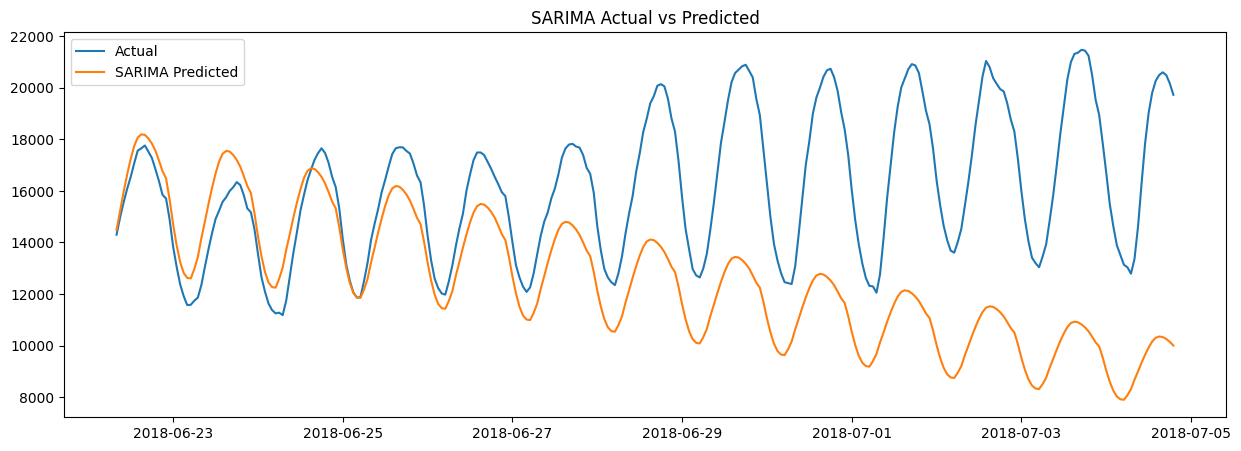

In [91]:
plt.figure(figsize=(15,5))

plt.plot(test.index[:300], test.iloc[:300], label="Actual")

plt.plot(test.index[:300], sarima_pred.iloc[:300], label="SARIMA Predicted")

plt.legend()
plt.title("SARIMA Actual vs Predicted")
plt.show()

# Prophet

In [92]:
from prophet import Prophet

In [93]:
series

Datetime
2018-01-06 16:00:00    19328.0
2018-01-06 17:00:00    19618.0
2018-01-06 18:00:00    20639.0
2018-01-06 19:00:00    21388.0
2018-01-06 20:00:00    21510.0
                        ...   
2018-08-02 20:00:00    17673.0
2018-08-02 21:00:00    17303.0
2018-08-02 22:00:00    17001.0
2018-08-02 23:00:00    15964.0
2018-08-03 00:00:00    14809.0
Freq: h, Name: AEP_MW, Length: 5001, dtype: float64

In [94]:
print(series.index)

DatetimeIndex(['2018-01-06 16:00:00', '2018-01-06 17:00:00',
               '2018-01-06 18:00:00', '2018-01-06 19:00:00',
               '2018-01-06 20:00:00', '2018-01-06 21:00:00',
               '2018-01-06 22:00:00', '2018-01-06 23:00:00',
               '2018-01-07 00:00:00', '2018-01-07 01:00:00',
               ...
               '2018-08-02 15:00:00', '2018-08-02 16:00:00',
               '2018-08-02 17:00:00', '2018-08-02 18:00:00',
               '2018-08-02 19:00:00', '2018-08-02 20:00:00',
               '2018-08-02 21:00:00', '2018-08-02 22:00:00',
               '2018-08-02 23:00:00', '2018-08-03 00:00:00'],
              dtype='datetime64[ns]', name='Datetime', length=5001, freq='h')


In [95]:
series.values

array([19328., 19618., 20639., ..., 17001., 15964., 14809.], shape=(5001,))

In [96]:
prophet_df=pd.DataFrame({"ds":series.index, "y":series.values})

In [97]:
prophet_df.head()

,ds,y
0,2018-01-06 16:00:00,19328.0
1,2018-01-06 17:00:00,19618.0
2,2018-01-06 18:00:00,20639.0
3,2018-01-06 19:00:00,21388.0
4,2018-01-06 20:00:00,21510.0


In [98]:
train_size=int(len(prophet_df)*0.8)

train_prophet=prophet_df.iloc[:train_size]

test_prophet=prophet_df.iloc[train_size:]

print("Train Size:", len(train_prophet))

print("Test Size:", len(test_prophet))

Train Size: 4000
Test Size: 1001


In [99]:
prophet_model=Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=False)

prophet_model.fit(train_prophet)

19:04:21 - cmdstanpy - INFO - Chain [1] start processing
19:04:22 - cmdstanpy - INFO - Chain [1] done processing


In [100]:
future=test_prophet[["ds"]]

prophet_forecast=prophet_model.predict(future)

prophet_pred=prophet_forecast["yhat"]

In [104]:
prophet_mae=mean_absolute_error(test_prophet["y"], prophet_pred)
prophet_r2=r2_score(test_prophet["y"], prophet_pred)

print("Prophet MAE:", prophet_mae)
print("Prophet R2:", prophet_r2)

Prophet MAE: 2302.683003768577
Prophet R2: 0.01823150450475708


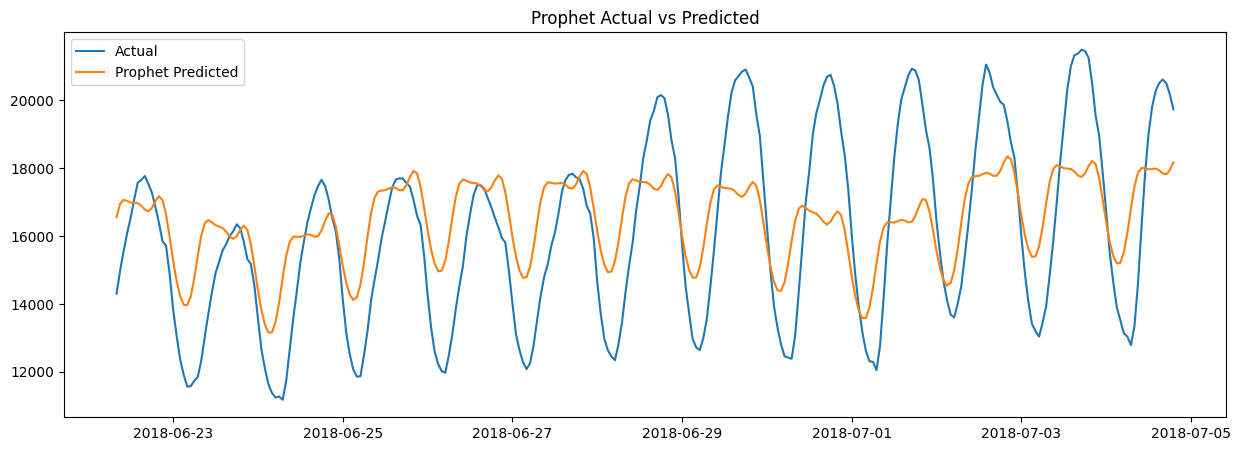

In [105]:
plt.figure(figsize=(15,5))

plt.plot(test_prophet["ds"].iloc[:300], test_prophet["y"].iloc[:300], label="Actual")
plt.plot(test_prophet["ds"].iloc[:300], prophet_pred.iloc[:300], label="Prophet Predicted")

plt.legend()
plt.title("Prophet Actual vs Predicted")
plt.show()

**It is not designed to learn complex nonlinear relationships like Random Forest.**

# As a result, Random Forest has a good MAE score of 173.47 and R2 of 98.78%.

# The mean of AEP_MW is 15498.35 and the (MAE/15498.35)*100 is 1.12%. So, MAE corresponds to approximately 1.12% of the mean demand.

# Therefore, the final forecasting model is selected as Random Forest.

# Model Comparison

**The performance of all forecasting models was evaluated using MAE, RMSE, and R² Score. Higher R² and lower MAE/RMSE indicate better predictive performance.**

In [108]:
results = pd.DataFrame({
    "Model": ["Baseline", "Random Forest", "XGBoost", "ARIMA", "SARIMA", "Prophet"],
    "MAE": [lr_mae, rf_mae, xgb_mae, arima_mae, sarima_mae, prophet_mae],
    "R2 Score": [lr_r2, rf_r2, xgb_r2, arima_r2, sarima_r2, prophet_r2]})

results = results.sort_values(by="R2 Score", ascending=False)

results

,Model,MAE,R2 Score
1,Random Forest,173.477821,0.987829
2,XGBoost,182.964531,0.987460
0,Baseline,404.275550,0.953808
5,Prophet,2302.683004,0.018232
3,ARIMA,2199.238967,-0.064928
4,SARIMA,9091.879370,-12.870072


Although XGBoost is generally more powerful, our dataset contained well-engineered lag features and structured temporal patterns. Random Forest was able to capture these effectively while remaining robust to overfitting. The performance difference was small, suggesting the additional boosting complexity did not provide a significant advantage for this particular forecasting task

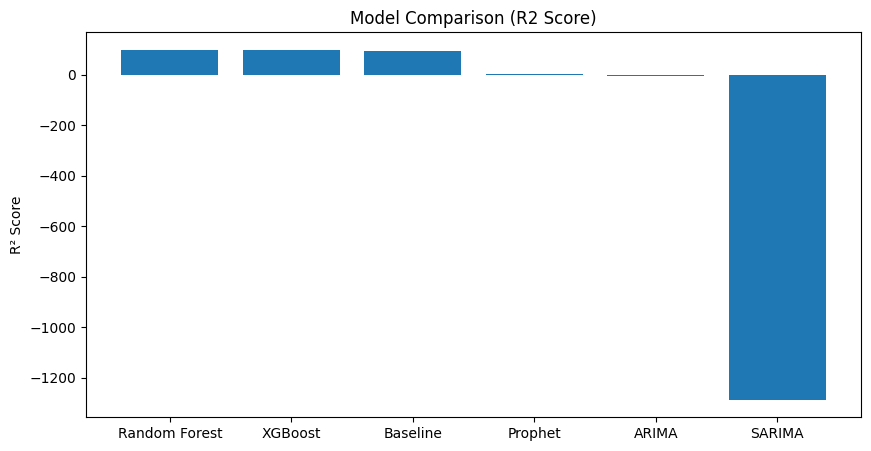

In [116]:
plt.figure(figsize=(10,5))

plt.bar(results["Model"], results["R2 Score"]*100)

plt.title("Model Comparison (R2 Score)")
plt.ylabel("R² Score")
plt.show()

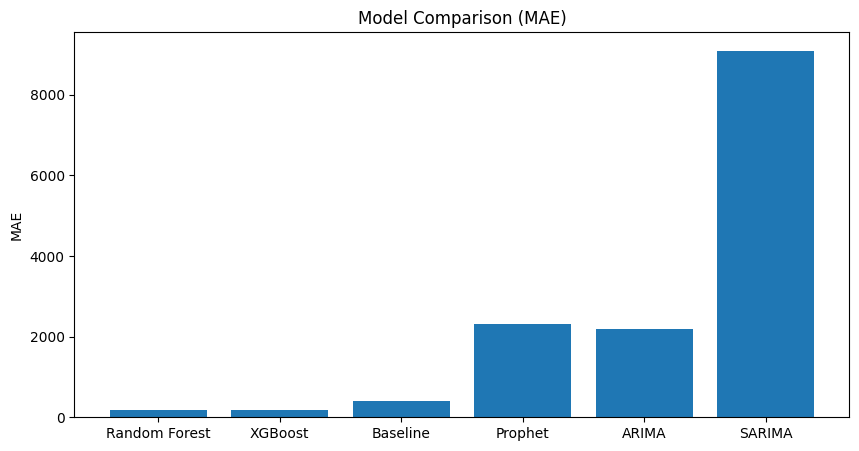

In [117]:
plt.figure(figsize=(10,5))

plt.bar(results["Model"], results["MAE"])

plt.title("Model Comparison (MAE)")
plt.ylabel("MAE")
plt.show()

# Conclusion

This project compared six different approaches for forecasting electricity demand, including a Baseline model, Random Forest, XGBoost, ARIMA, SARIMA, and Prophet.

Among all the models, **Random Forest achieved the best overall performance**, producing the lowest prediction error (MAE) and the highest R² score. XGBoost followed closely behind, delivering very similar results. These findings demonstrate that tree-based ensemble learning algorithms are highly effective at capturing the complex, non-linear patterns present in electricity demand data.

Traditional statistical models such as ARIMA and SARIMA were able to model temporal relationships but were less effective than the machine learning approaches on this dataset. Prophet successfully captured the overall trend and seasonality; however, it was unable to predict short-term fluctuations with the same level of accuracy as Random Forest and XGBoost.

Feature importance analysis revealed that lag-based features, particularly **lag_1**, contributed the most to the model's predictions, highlighting the strong temporal dependency in electricity demand forecasting.

Overall, this project demonstrates that machine learning models, especially **Random Forest**, provide superior forecasting performance for this dataset when combined with effective feature engineering. The results also emphasize the importance of selecting an appropriate forecasting approach based on the characteristics of the data rather than assuming a single model will always perform best.